# Upstream tutorial: CUT&RUN

This notebook is an `epione`-native adaptation of the Galaxy Training Network CUT&RUN tutorial. The overall aim is to start from paired-end FASTQ files, preprocess each replicate, merge them into an experiment-level BAM, generate a bigWig signal track, call peaks, and then inspect whether the resulting signal behaves as expected at both a representative locus and around transcription start sites.

The Galaxy lesson teaches this as a browser-based workflow made of multiple tool invocations. Here we keep the same conceptual sequence, but express the workflow as a compact set of `epi.upstream.*` calls so that the notebook doubles as a reusable pipeline prototype for the OTX2 project.

As in the ATAC notebook, the example is deliberately engineered to be executable. We therefore use the small public GTN teaching FASTQs and a lightweight `chr22` reference derived from a local GRCh38 cache. That allows the full workflow to run in `omicdev` while preserving the important CUT&RUN ideas: replicate-aware preprocessing, merged coverage generation, peak calling, browser-style signal inspection, and promoter-centred aggregation.


> **Scope note.** This notebook focuses on the *upstream* path of a bulk CUT&RUN analysis: `FASTQ -> per-replicate BAM -> merged BAM -> bigWig -> peaks -> visual QC`. It does **not** attempt to cover full replicate concordance statistics, motif analysis, or downstream comparative biology.

### Data provenance

The example inputs are the small replicate FASTQs distributed with the Galaxy Training Network CUT&RUN tutorial. They are designed for teaching, but they preserve an important real-world property that many toy datasets omit: a two-replicate structure that has to be processed and then merged.

| Item | Source | How it is used here |
| --- | --- | --- |
| **Rep1 / Rep2 paired-end FASTQs** | Galaxy GTN CUT&RUN tutorial toy dataset | Demonstrate replicate-level preprocessing and experiment-level merging. |
| **GRCh38 FASTA** | Local cache on this machine | Used to derive a small executable `chr22` reference. |
| **Merged peak locus** | Chosen from the strongest MACS2 peak in the merged demo run | Used for a compact browser-style quality check. |

Local paths used throughout the notebook:

```text
case/otx2/galaxy_cutrun_demo/
  fastq/     # downloaded GTN toy FASTQs
  ref/       # chr22 FASTA + bowtie2 index + derived annotation
  result/    # replicate BAMs, merged BAM, bigWigs, MACS2 peaks
```

### Learning goals

By the end of the notebook, you should be able to answer five practical questions:

1. How does `epione` represent the replicate-aware structure of a CUT&RUN preprocessing run?
2. Which part of the workflow is per-replicate, and which part is experiment-level?
3. How do we convert merged alignments into both a signal track and a peak set?
4. What does a reasonable merged CUT&RUN peak look like in a local browser plot?
5. How can the same compact API be transferred to the real OTX2 CUT&RUN samples?


In [1]:
import os
import pathlib
import urllib.request
import warnings

import pandas as pd
import epione as epi

warnings.filterwarnings('ignore', message='Function .* is missing a docstring.*')
os.environ['LC_ALL'] = 'C'
os.environ['LC_CTYPE'] = 'C'

epi.pl.plot_set()

WORK = pathlib.Path.cwd()
DATA = WORK / 'galaxy_cutrun_demo'
FASTQ_DIR = DATA / 'fastq'
REF_DIR = DATA / 'ref'
OUT = DATA / 'result'
for p in [FASTQ_DIR, REF_DIR, OUT]:
    p.mkdir(parents=True, exist_ok=True)

HG38_FASTA = pathlib.Path('/scratch/users/steorra/data/snapatac2_cache/gencode_v41_GRCh38.fa.gz.decomp')
CHR22_FASTA = REF_DIR / 'chr22.fa'
CHR22_BT2_PREFIX = REF_DIR / 'chr22'
CHR22_SIZE = 50818468

CUTRUN_URLS = {
    'Rep1_R1.fastq': 'https://zenodo.org/record/6823059/files/Rep1_R1.fastq',
    'Rep1_R2.fastq': 'https://zenodo.org/record/6823059/files/Rep1_R2.fastq',
    'Rep2_R1.fastq': 'https://zenodo.org/record/6823059/files/Rep2_R1.fastq',
    'Rep2_R2.fastq': 'https://zenodo.org/record/6823059/files/Rep2_R2.fastq',
}


/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/_registry.py:241: UserWarning: Function 'omicverse.alignment.dada2.merge_pairs' is missing a docstring; agent help output may be limited.
  warnings.warn(
/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/_registry.py:241: UserWarning: Function 'omicverse.alignment.dada2.make_seqtab' is missing a docstring; agent help output may be limited.
  warnings.warn(
/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/_registry.py:241: UserWarning: Function 'omicverse.alignment.dada2.remove_chimeras' is missing a docstring; agent help output may be limited.
  warnings.warn(


└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



## 1. Check upstream tools

Even in a notebook-driven `epione` workflow, CUT&RUN preprocessing still depends on the usual alignment and BAM-processing ecosystem. The Galaxy tutorial hides that complexity behind separate tool forms; here we surface it explicitly before the first compute-heavy step.

The dependency check matters for two reasons. First, it makes the notebook more robust to reruns in a shared environment. Second, it clarifies which steps are genuinely handled by `epione` logic and which still rely on established external bioinformatics tools.

| Tool family | Why it matters |
| --- | --- |
| `bowtie2` | Aligns paired-end CUT&RUN reads to the reference. |
| `samtools` | Sorts, filters, merges, and indexes BAM files. |
| `bedtools` | Supports interval-aware BAM-to-region conversions. |
| `MACS2` | Calls peaks from the merged alignment. |
| `epione` built-in bigWig writer | Default route for exporting normalized bigWig signal inside the Python workflow. |

A short environment check is therefore not boilerplate. It is the fastest way to catch missing external dependencies before replicate processing starts.


In [2]:
epi.upstream.check_tools([
    'bowtie2',
    'samtools',
    'bedtools',
    'macs2',
])


  ✓  bowtie2                    /scratch/users/steorra/env/omicdev/bin/bowtie2
  ✓  samtools                   /scratch/users/steorra/env/omicdev/bin/samtools
  ✓  bedtools                   /scratch/users/steorra/env/omicdev/bin/bedtools
  ✓  macs2                      /scratch/users/steorra/env/omicdev/bin/macs2


{'bowtie2': '/scratch/users/steorra/env/omicdev/bin/bowtie2',
 'samtools': '/scratch/users/steorra/env/omicdev/bin/samtools',
 'bedtools': '/scratch/users/steorra/env/omicdev/bin/bedtools',
 'macs2': '/scratch/users/steorra/env/omicdev/bin/macs2'}

## 2. Download the Galaxy toy FASTQs

The input files are the two replicate pairs from the Galaxy GTN CUT&RUN tutorial. These FASTQs are intentionally compact, but unlike many toy datasets they still preserve the replicate structure that matters for a realistic CUT&RUN workflow.

That design is useful pedagogically because it lets the notebook teach two layers of reasoning at once:

- **replicate-level preprocessing**, where each pair is aligned and filtered independently, and
- **experiment-level summarisation**, where the processed replicates are merged into a combined signal and peak set.

At this stage the notebook is simply establishing the raw inputs. Once the four FASTQs are present, the remaining steps can be expressed entirely through `epi.upstream.*` functions without any Galaxy-style dataset collection management.


In [3]:
for name, url in CUTRUN_URLS.items():
    out = FASTQ_DIR / name
    if not out.exists():
        print(f'downloading {name} ...')
        urllib.request.urlretrieve(url, out)
    else:
        print(f'skip existing: {name}')

pairs = [
    ('Rep1', FASTQ_DIR / 'Rep1_R1.fastq', FASTQ_DIR / 'Rep1_R2.fastq'),
    ('Rep2', FASTQ_DIR / 'Rep2_R1.fastq', FASTQ_DIR / 'Rep2_R2.fastq'),
]
pd.DataFrame({
    'sample': [s for s, _, _ in pairs],
    'fq1': [str(r1) for _, r1, _ in pairs],
    'fq2': [str(r2) for _, _, r2 in pairs],
})


skip existing: Rep1_R1.fastq
skip existing: Rep1_R2.fastq
skip existing: Rep2_R1.fastq
skip existing: Rep2_R2.fastq


,sample,fq1,fq2
0,Rep1,/scratch/users/steorra/analysis/omicverse_dev/...,/scratch/users/steorra/analysis/omicverse_dev/...
1,Rep2,/scratch/users/steorra/analysis/omicverse_dev/...,/scratch/users/steorra/analysis/omicverse_dev/...


## 3. Prepare a `chr22` demo reference

As in the ATAC tutorial, the full human reference would be unnecessary overhead for a notebook whose purpose is to demonstrate workflow structure rather than produce publication-scale outputs. We therefore derive a small `chr22` reference from a locally cached GRCh38 FASTA.

This reduced reference keeps the executable example aligned with the constraints of the local environment while still supporting the essential CUT&RUN operations: alignment, replicate processing, merging, coverage export, peak calling, and signal aggregation.

`epi.upstream.prepare_reference(...)` centralizes a step that often ends up scattered across shell commands. The point is not only convenience. It also guarantees that later `epione` calls are all reading from the same reference bundle rather than relying on loosely coordinated index files on disk.


In [4]:
%%time
from pyfaidx import Fasta

if not CHR22_FASTA.exists():
    fa = Fasta(str(HG38_FASTA))
    with open(CHR22_FASTA, 'w') as fout:
        fout.write('>chr22\n')
        seq = str(fa['chr22'])
        for i in range(0, len(seq), 60):
            fout.write(seq[i:i+60] + '\n')

ref = epi.upstream.prepare_reference(
    fasta=CHR22_FASTA,
    aligner='bowtie2',
    index_prefix=CHR22_BT2_PREFIX,
)
ref


CPU times: user 3.17 ms, sys: 910 μs, total: 4.08 ms
Wall time: 6.05 ms


{'fasta': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/ref/chr22.fa',
 'fai': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/ref/chr22.fa.fai',
 'chrom_sizes': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/ref/chr22.chrom.sizes',
 'ref_index': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/ref/chr22'}

## 4. Process each replicate step by step

The Galaxy CUT&RUN lesson describes a sequence of trimming, alignment, filtering, duplicate removal, and coverage export. In `epione` we now represent that same logic explicitly instead of hiding it inside a single helper.

For each replicate we run:

1. `epi.upstream.bowtie2.align_fastq_to_bam(...)` to build the coordinate-sorted BAM.
2. `epi.upstream.samtools.filter_bam(...)` to define the retained alignment set.
3. `epi.upstream.samtools.index_bam(...)` so the filtered BAM can be reused directly.
4. `epi.upstream.bigwig.bam_to_bigwig(...)` to export the replicate signal track.

This makes the replicate structure very clear. Each replicate leaves behind its own filtered BAM and bigWig before any merge occurs.


In [5]:
%%time
cutrun_runs = {}
for sample_name, fq1, fq2 in pairs:
    sample_dir = OUT / sample_name
    sample_dir.mkdir(parents=True, exist_ok=True)
    raw_bam = sample_dir / f'{sample_name}.raw.bam'
    filt_bam = sample_dir / f'{sample_name}.filtered.bam'
    bw_path = sample_dir / f'{sample_name}.rpkm.bw'

    for stale in [raw_bam, filt_bam, pathlib.Path(str(filt_bam) + '.bai'), bw_path]:
        if stale.exists():
            stale.unlink()

    epi.upstream.bowtie2.align_fastq_to_bam(
        fq1=str(fq1),
        fq2=str(fq2),
        out_bam=raw_bam,
        ref_index=ref['ref_index'],
        threads=8,
        extra_args=[
            '--end-to-end', '--very-sensitive', '--no-mixed', '--no-discordant',
            '-I', '10', '-X', '700',
        ],
        remove_duplicates=True,
    )
    epi.upstream.samtools.filter_bam(
        raw_bam,
        filt_bam,
        mapq=30,
        proper_pair=True,
        drop_secondary_supp=True,
        drop_duplicates=False,
        drop_qcfail=False,
        drop_unmapped=True,
        drop_mate_unmapped=True,
        threads=8,
    )
    epi.upstream.samtools.index_bam(filt_bam, threads=8)
    epi.upstream.bigwig.bam_to_bigwig(
        filt_bam,
        bw_path,
        bin_size=100,
        normalize_using='RPKM',
        threads=8,
    )
    raw_bam.unlink(missing_ok=True)
    cutrun_runs[sample_name] = {'bam': str(filt_bam), 'bigwig': str(bw_path)}

pd.DataFrame(cutrun_runs).T


[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


300000 reads; of these:
  300000 (100.00%) were paired; of these:
    295253 (98.42%) aligned concordantly 0 times
    1716 (0.57%) aligned concordantly exactly 1 time
    3031 (1.01%) aligned concordantly >1 times
1.58% overall alignment rate
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


300000 reads; of these:
  300000 (100.00%) were paired; of these:
    294454 (98.15%) aligned concordantly 0 times
    2106 (0.70%) aligned concordantly exactly 1 time
    3440 (1.15%) aligned concordantly >1 times
1.85% overall alignment rate
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


CPU times: user 4.94 s, sys: 117 ms, total: 5.06 s
Wall time: 11.6 s


,bam,bigwig
Rep1,/scratch/users/steorra/analysis/omicverse_dev/...,/scratch/users/steorra/analysis/omicverse_dev/...
Rep2,/scratch/users/steorra/analysis/omicverse_dev/...,/scratch/users/steorra/analysis/omicverse_dev/...


## 5. Merge replicate BAMs and export the experiment-level track

Once both replicates have been processed individually, we switch from replicate-level reasoning to experiment-level summarisation.

| Operation | `epione` function | Purpose |
| --- | --- | --- |
| **Merge filtered replicate BAMs** | `epi.upstream.samtools.merge_bams(...)` | Produces one experiment-level alignment from the retained replicate reads. |
| **Export merged coverage** | `epi.upstream.bigwig.bam_to_bigwig(...)` | Creates the combined signal track used for visualization and matrix aggregation. |

This keeps the provenance clean: replicate BAMs remain available, but the merged signal is what we inspect for the rest of the tutorial.


In [6]:
%%time
merged_dir = OUT / 'merged'
merged_dir.mkdir(parents=True, exist_ok=True)
for stale in [merged_dir / 'Rep12.filtered.bam', merged_dir / 'Rep12.filtered.bam.bai', merged_dir / 'Rep12.rpkm.bw']:
    if stale.exists():
        stale.unlink()

merged_bam = epi.upstream.samtools.merge_bams(
    [cutrun_runs['Rep1']['bam'], cutrun_runs['Rep2']['bam']],
    merged_dir / 'Rep12.filtered.bam',
    threads=8,
    index=True,
)
merged_bw = epi.upstream.bigwig.bam_to_bigwig(
    merged_bam,
    merged_dir / 'Rep12.rpkm.bw',
    bin_size=100,
    normalize_using='RPKM',
    threads=8,
)
{'merged_bam': merged_bam, 'merged_bigwig': merged_bw}


CPU times: user 2.53 s, sys: 49.7 ms, total: 2.58 s
Wall time: 2.64 s


{'merged_bam': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/result/merged/Rep12.filtered.bam',
 'merged_bigwig': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/result/merged/Rep12.rpkm.bw'}

## 6. Peak calling on the merged BAM

After merging, the next goal is to summarize the strongest reproducible enrichment events as a standard peak set. In the Galaxy tutorial, this step comes after mapping and filtering once the signal is judged clean enough to support interval-level interpretation.

### The function

`epi.upstream.macs2.call_peaks_macs2(...)` provides the thin `epione` wrapper around MACS2 peak calling.

| Key parameter | What it controls |
| --- | --- |
| `bam` | The merged experiment-level alignment used as input signal. |
| `format='BAMPE'` | Uses paired-end fragment logic. |
| `qvalue` | Reporting threshold for significant peaks. |
| `call_summits=True` | Requests local summit positions inside peaks. |
| `nomodel=True` | Skips model building, which is often appropriate in CUT&RUN-like workflows. |

Because the executable notebook uses a reduced `chr22` reference, the emphasis is on producing a coherent tutorial output that can be interpreted visually rather than a definitive biological peak catalogue.


In [7]:
%%time
peak_paths = epi.upstream.macs2.call_peaks_macs2(
    bam=merged_bam,
    out_dir=OUT / 'peaks',
    name='Rep12',
    genome_size=str(CHR22_SIZE),
    format='BAMPE',
    qvalue=0.01,
    keep_dup='all',
    call_summits=True,
    nomodel=True,
)
peak_paths


CPU times: user 466 μs, sys: 1.03 ms, total: 1.49 ms
Wall time: 128 ms


INFO  @ Thu, 23 Apr 2026 05:52:44: 
# Command line: callpeak -t /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/result/merged/Rep12.filtered.bam -f BAMPE -g 50818468 --keep-dup all -q 0.01 -n Rep12 --outdir /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/result/peaks --nomodel --call-summits
# ARGUMENTS LIST:
# name = Rep12
# format = BAMPE
# ChIP-seq file = ['/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/result/merged/Rep12.filtered.bam']
# control file = None
# effective genome size = 5.08e+07
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 1.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 10000 bps
# Broad region calling is off
# Paired-End mode is

{'narrowPeak': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/result/peaks/Rep12_peaks.narrowPeak',
 'summits': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/result/peaks/Rep12_summits.bed',
 'xls': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/result/peaks/Rep12_peaks.xls'}

## 7. Visualise the strongest merged CUT&RUN peak

A peak file is useful, but it is still a summary object. The next step is to verify that at least one representative peak is visually supported by a clear local enrichment profile in the merged bigWig. This mirrors the logic of the Galaxy tutorial, which spends substantial effort on interpreting coverage rather than treating the peak caller as infallible.

### Biological question

Does the top merged peak correspond to a sharp, localized coverage enrichment in the merged CUT&RUN track?

### The function

`epi.bulk.bigwig(...).plot_track(...)` renders the merged bigWig as a browser-style track around a chosen genomic window.

| Key parameter | What it controls |
| --- | --- |
| `chrom`, `chromstart`, `chromend` | The local genomic window to display. |
| `plot_names` | Which registered bigWig tracks are shown. |
| `bp_per_bin` | Horizontal aggregation resolution. |
| `region_dict` | Highlight intervals, here the top merged peak. |
| `color_dict` | Per-track visual styling. |

### How to read the plot

The key consistency check is simple: the highlighted peak interval should sit on top of a visibly enriched signal profile rather than a flat or noisy background. That does not prove biological correctness on its own, but it is one of the fastest local sanity checks for a compact CUT&RUN demo.


└─ Load bigWig files
  └─ Loading Rep12 CUT&RUN...


(<Figure size 640x144 with 1 Axes>, [<Axes: ylabel='Rep12 CUT&RUN'>])

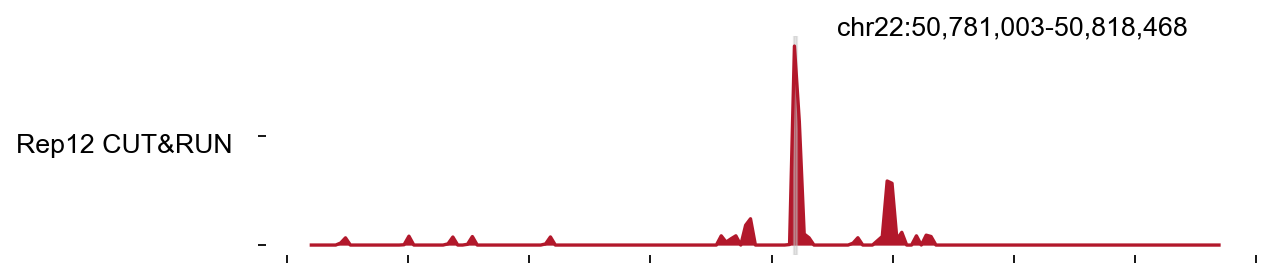

In [8]:
peak_df = pd.read_csv(peak_paths['narrowPeak'], sep='	', header=None)
top_peak = peak_df.sort_values(6, ascending=False).iloc[0]
chrom = str(top_peak[0])
center = int((int(top_peak[1]) + int(top_peak[2])) / 2)

bw_obj = epi.bulk.bigwig({'Rep12 CUT&RUN': merged_bw})
bw_obj.read()
chrom_len = bw_obj.bw_dict['Rep12 CUT&RUN'].chroms()[chrom]
start = max(0, center - 20000)
end = min(int(chrom_len), center + 20000)
region_dict = {'top_peak': (int(top_peak[1]), int(top_peak[2]))}
color_dict = {'Rep12 CUT&RUN': '#B2182B'}

bw_obj.plot_track(
    chrom=chrom,
    chromstart=start,
    chromend=end,
    plot_names=['Rep12 CUT&RUN'],
    figwidth=8,
    figheight=1.8,
    color_dict=color_dict,
    bp_per_bin=200,
    region_dict=region_dict,
)


## 8. Compute a TSS heatmap with `epi.bulk.bigwig`

The local browser view above answers a single-locus question. To add a more global summary, we also compute a TSS-centred signal matrix and render it as a heatmap plus a mean profile. This plays the same pedagogical role as the matrix-aggregation steps commonly shown in Galaxy tutorials.

### Biological question

When the merged CUT&RUN bigWig is summarized around annotated transcription start sites, does it show structured promoter-proximal signal rather than an undifferentiated background profile?

### Why derive a small `chr22` GTF?

The notebook uses a reduced `chr22` reference, so the annotation has to match that reduced coordinate system. Rather than shipping a separate annotation file just for the tutorial, we derive a minimal transcript-only GTF from the local GRCh38 GENCODE `gff3`.

### The functions

This section uses the same matrix workflow taught elsewhere in `epione`:

1. `load_gtf(...)` registers transcript coordinates.
2. `compute_matrix(...)` aggregates signal around TSSs.
3. `plot_matrix(...)` visualizes the per-gene matrix.
4. `plot_matrix_line(...)` shows the average TSS profile.

| Output | Interpretation |
| --- | --- |
| **Heatmap** | Whether promoter-proximal enrichment is broadly present across genes. |
| **Mean profile** | Whether signal is centered near the TSS rather than uniformly flat. |

Together, the locus plot and the TSS matrix provide a local-plus-global view of the merged CUT&RUN signal quality.


In [9]:
GENCODE_GFF3 = pathlib.Path('/scratch/users/steorra/data/snapatac2_cache/gencode_v41_GRCh38.gff3.gz')
CHR22_GTF = REF_DIR / 'gencode_v41_chr22.transcripts.gtf'

CHR22_GTF = pathlib.Path(
    epi.utils.convert_gff_to_gtf(
        GENCODE_GFF3,
        CHR22_GTF,
        feature_whitelist=['transcript'],
        seqname_whitelist=['chr22'],
    )
)

with open(CHR22_GTF) as fin:
    transcript_count = sum(1 for _ in fin)

print(CHR22_GTF, transcript_count)


└─ Converting GFF to GTF: /scratch/users/steorra/data/snapatac2_cache/gencode_v41_GRCh38.gff3.gz -> /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/ref/gencode_v41_chr22.transcripts.gtf


└─ Wrote 3939 GTF records
/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/ref/gencode_v41_chr22.transcripts.gtf 3939


└─ Load bigWig files
  └─ Loading Rep12 CUT&RUN...
└─ Load GTF file
  ├─ Reading GTF...
  └─ Reading GTF file from /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_cutrun_demo/ref/gencode_v41_chr22.transcripts.gtf...
  └─ GTF file read successfully
  └─ GTF loaded
└─ Compute matrix: Rep12 CUT&RUN
  ├─ Prepare features
  ├─ Build matrices


Chromosomes:   0%|                                                                                                | 0/1 [00:00<?, ?chr/s]

Chromosomes: 100%|████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.87chr/s]

Chromosomes: 100%|████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.87chr/s]

  └─ Finalize
  └─ Rep12 CUT&RUN matrix finished
  └─ Rep12 CUT&RUN tss matrix in bw_tss_scores_dict[Rep12 CUT&RUN]
  └─ Rep12 CUT&RUN tes matrix in bw_tes_scores_dict[Rep12 CUT&RUN]
  └─ Rep12 CUT&RUN body matrix in bw_body_scores_dict[Rep12 CUT&RUN]


(<Figure size 256x208 with 1 Axes>,
 <Axes: title={'center': 'CUT&RUN TSS mean'}>)

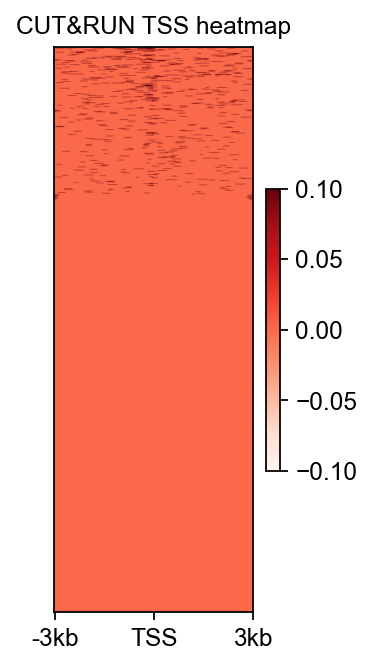

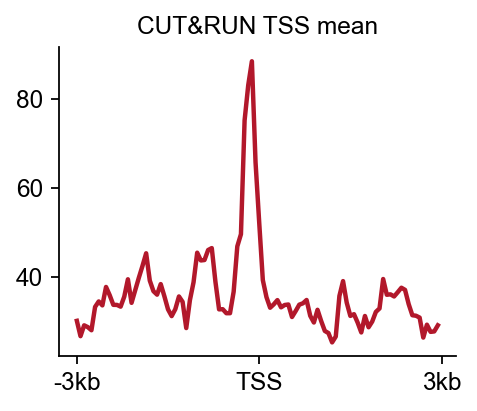

In [10]:
cutrun_tss = epi.bulk.bigwig({'Rep12 CUT&RUN': merged_bw})
cutrun_tss.read()
cutrun_tss.load_gtf(str(CHR22_GTF))
cutrun_tss.compute_matrix('Rep12 CUT&RUN', nbins=100, upstream=3000, downstream=3000, n_jobs=1)

fig, ax = cutrun_tss.plot_matrix(
    bw_name='Rep12 CUT&RUN',
    bw_type='TSS',
    figsize=(2.4, 4.2),
    cmap='Reds',
    vmax='auto',
    vmin='auto',
    fontsize=11,
    title='CUT&RUN TSS heatmap',
)

cutrun_tss.plot_matrix_line(
    bw_name='Rep12 CUT&RUN',
    bw_type='TSS',
    figsize=(3.2, 2.6),
    color='#B2182B',
    fontsize=11,
    title='CUT&RUN TSS mean',
)


## 9. OTX2 project template

The final code cell is the bridge from tutorial data to project data. It keeps the same explicit `epi.upstream.bowtie2 -> epi.upstream.samtools -> epi.upstream.bigwig -> epi.upstream.macs2` structure used above, but swaps the GTN FASTQs for the real OTX2 CUT&RUN inputs.

That is the main advantage of rewriting the workflow this way: the teaching notebook and the production notebook share the same step-by-step API rather than a notebook-only convenience wrapper.


In [11]:
# rep1_dir = WORK / 'otx2_upstream' / 'cutrun_rep1'
# rep2_dir = WORK / 'otx2_upstream' / 'cutrun_rep2'
# rep1_dir.mkdir(parents=True, exist_ok=True)
# rep2_dir.mkdir(parents=True, exist_ok=True)
#
# rep1_raw = rep1_dir / 'h_OTX2_day2_CUTRUN_rep1.raw.bam'
# rep1_bam = rep1_dir / 'h_OTX2_day2_CUTRUN_rep1.filtered.bam'
# rep1_bw = rep1_dir / 'h_OTX2_day2_CUTRUN_rep1.rpkm.bw'
# rep2_raw = rep2_dir / 'h_OTX2_day2_CUTRUN_rep2.raw.bam'
# rep2_bam = rep2_dir / 'h_OTX2_day2_CUTRUN_rep2.filtered.bam'
# rep2_bw = rep2_dir / 'h_OTX2_day2_CUTRUN_rep2.rpkm.bw'
#
# epi.upstream.bowtie2.align_fastq_to_bam(
#     fq1='/path/to/h_OTX2_day2_CUTRUN_rep1_R1.fastq.gz',
#     fq2='/path/to/h_OTX2_day2_CUTRUN_rep1_R2.fastq.gz',
#     out_bam=rep1_raw,
#     ref_index='/path/to/full/genome/index/prefix',
#     threads=8,
#     extra_args=['--end-to-end', '--very-sensitive', '--no-mixed', '--no-discordant', '-I', '10', '-X', '700'],
#     remove_duplicates=True,
# )
# epi.upstream.samtools.filter_bam(rep1_raw, rep1_bam, mapq=30, proper_pair=True, drop_secondary_supp=True, drop_unmapped=True, drop_mate_unmapped=True, threads=8)
# epi.upstream.samtools.index_bam(rep1_bam, threads=8)
# epi.upstream.bigwig.bam_to_bigwig(rep1_bam, rep1_bw, bin_size=100, normalize_using='RPKM', threads=8)
#
# epi.upstream.bowtie2.align_fastq_to_bam(
#     fq1='/path/to/h_OTX2_day2_CUTRUN_rep2_R1.fastq.gz',
#     fq2='/path/to/h_OTX2_day2_CUTRUN_rep2_R2.fastq.gz',
#     out_bam=rep2_raw,
#     ref_index='/path/to/full/genome/index/prefix',
#     threads=8,
#     extra_args=['--end-to-end', '--very-sensitive', '--no-mixed', '--no-discordant', '-I', '10', '-X', '700'],
#     remove_duplicates=True,
# )
# epi.upstream.samtools.filter_bam(rep2_raw, rep2_bam, mapq=30, proper_pair=True, drop_secondary_supp=True, drop_unmapped=True, drop_mate_unmapped=True, threads=8)
# epi.upstream.samtools.index_bam(rep2_bam, threads=8)
# epi.upstream.bigwig.bam_to_bigwig(rep2_bam, rep2_bw, bin_size=100, normalize_using='RPKM', threads=8)
#
# rep12_bam = epi.upstream.samtools.merge_bams([rep1_bam, rep2_bam], WORK / 'otx2_upstream' / 'cutrun_rep12.bam', threads=8)
# peak_paths = epi.upstream.macs2.call_peaks_macs2(
#     bam=rep12_bam,
#     out_dir=WORK / 'otx2_upstream' / 'peaks',
#     name='h_OTX2_day2_CUTRUN',
#     genome_size='hs',
#     format='BAMPE',
#     qvalue=0.01,
#     keep_dup='all',
#     call_summits=True,
#     nomodel=True,
# )
